In [113]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

plt.style.use("default")  # keep simple


# Use 'r' before the path and fix the quotes
file_path = r'C:\Users\sande\Downloads\pes\sem 6\vs code\ml project\sentiment-analysis-project\data\raw\reviews.csv'

# Load the dataset
df = pd.read_csv(file_path, index_col=0)

#save the result plot
import os
os.makedirs("results/figures", exist_ok=True)



1.Basic Dataset Understanding


In [114]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nMissing values:\n", df.isnull().sum())


Shape: (23486, 10)

Columns:
 Index(['Clothing ID', 'Age', 'Title', 'Review Text', 'Rating',
       'Recommended IND', 'Positive Feedback Count', 'Division Name',
       'Department Name', 'Class Name'],
      dtype='str')

Missing values:
 Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64


titles are missing titles missing and it is like 

🔹 2. Rating Distribution (IMPORTANT)

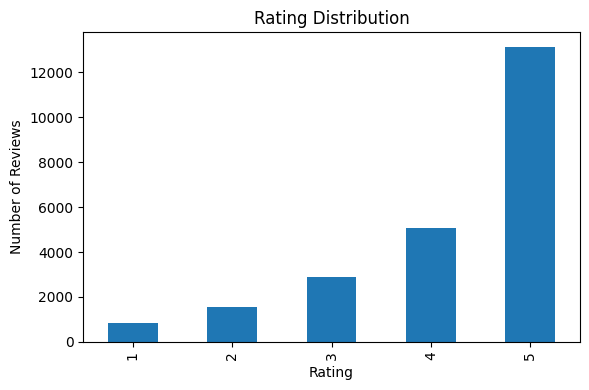

In [115]:
plt.figure(figsize=(6,4))
df["Rating"].value_counts().sort_index().plot(kind="bar")

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.savefig("results/figures/rating_distribution.png")
plt.show()

🔹 3. Convert Rating → Sentiment

In [116]:
def rating_to_sentiment(rating):
    if rating >= 4:
        return "positive"
    elif rating <= 2:
        return "negative"
    else:
        return "neutral"

df["sentiment"] = df["Rating"].apply(rating_to_sentiment)

df["sentiment"].value_counts()



sentiment
positive    18208
neutral      2871
negative     2407
Name: count, dtype: int64

4. sentimental analysis

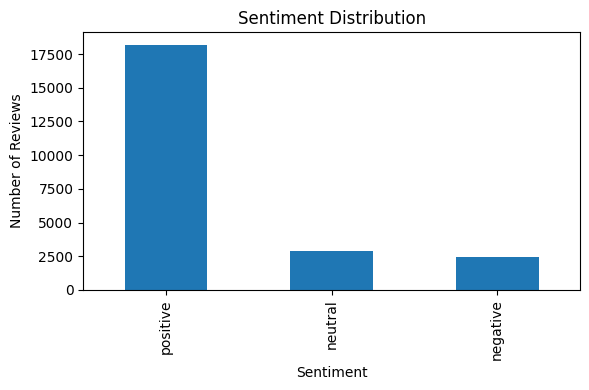

In [117]:
plt.figure(figsize=(6,4))
df["sentiment"].value_counts().plot(kind="bar")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.savefig("results/figures/sentiment_distribution.png")
plt.show()


In [118]:
🔹 5. Review Length Analysis

SyntaxError: invalid character '🔹' (U+1F539) (1876934091.py, line 1)

In [ ]:
df["char_length"] = df["Review Text"].fillna("").apply(len)
df["word_count"] = df["Review Text"].fillna("").apply(lambda x: len(x.split()))
df[["Review Text", "char_length", "word_count"]].head()

,Review Text,char_length,word_count
0,Absolutely wonderful - silky and sexy and comf...,53,8
1,Love this dress! it's sooo pretty. i happene...,303,62
2,I had such high hopes for this dress and reall...,500,98
3,"I love, love, love this jumpsuit. it's fun, fl...",124,22
4,This shirt is very flattering to all due to th...,192,36


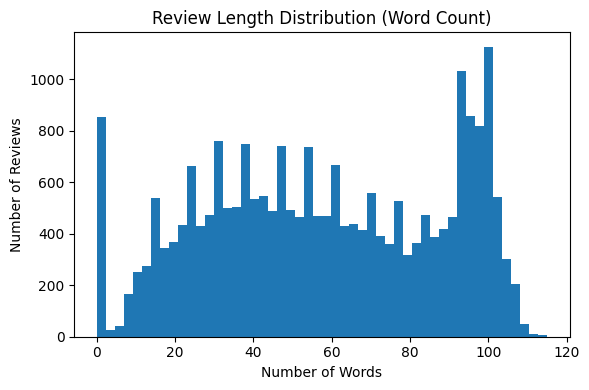

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(df["word_count"], bins=50)

plt.title("Review Length Distribution (Word Count)")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.savefig("results/figures/review_length_distribution.png")
plt.show()


6. Review Length vs Sentiment

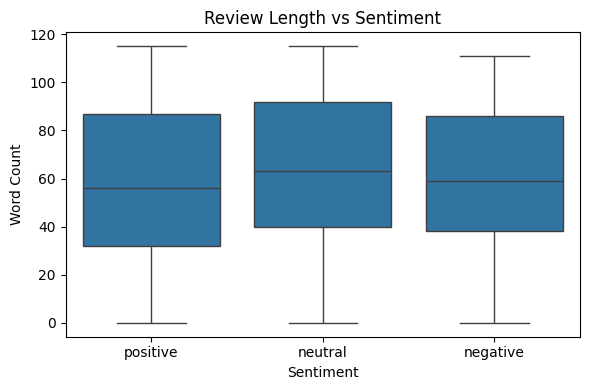

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x="sentiment", y="word_count", data=df)

plt.title("Review Length vs Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Word Count")
plt.tight_layout()
plt.savefig("results/figures/review_length_vs_sentiment.png")
plt.show()


7. Word Cloud (Text Understanding)

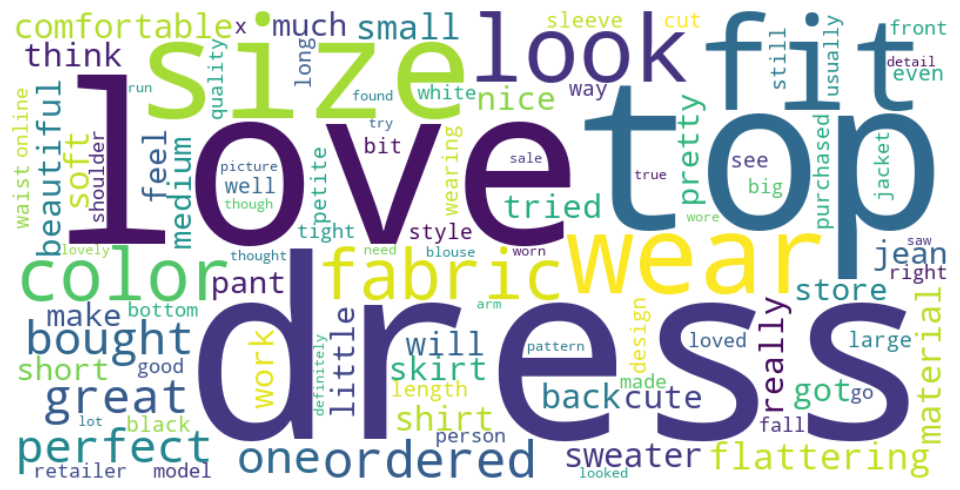

In [ ]:
text = " ".join(df["Review Text"].dropna().astype(str))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=100
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.tight_layout()
plt.savefig("results/figures/wordcloud.png")
plt.show()


8. Manual Review Inspection (CRITICAL)

In [ ]:
print("POSITIVE REVIEWS:\n")
for review in df[df["sentiment"] == "positive"]["Review Text"].sample(5):
    print(review)
    print("-" * 60)

print("\nNEGATIVE REVIEWS:\n")
for review in df[df["sentiment"] == "negative"]["Review Text"].sample(5):
    print(review)
    print("-" * 60)


POSITIVE REVIEWS:

Love the lightweight fabric! looks great with skinny jeans. it is flowy, but flattering.
wearing it on my shoulders for work -
------------------------------------------------------------
I got this in blue and also in white, both size medium. it's a very comfy casual top and i love the horseshoe neckline and front facing seaming which makes it just a bit different. however....i can't figure out why the blue color fits quite a bit smaller than the white. but it does, so consider this when you order, depending upon how you want it to fit. i'm keeping both but will wear the blue in a different way, definitely not with leggings.
------------------------------------------------------------
I tried this dress on in the store, and nearly bought it. other reviewers commented on the tight chest, but i must admit, this was the one part of the dress that fit like a dream on me. however, i am very small busted (34a). the waist is very flattering, as well. but, the skirt seemed 